# Python у Stack Overflow Developer Survey 2025

**Мета:** дослідити, хто користується Python, як люди вчаться програмувати
та як це пов'язано з віком, країною і рівнем компенсації.

**Дані:** результати опитування Stack Overflow 2025 (~49 тис. респондентів, 172 питання).
**Інструменти:** Python, pandas, Google Colab.

##  Підготовка даних

Завантажуємо результати опитування та схему (опис питань) напряму
з офіційного репозиторію Stack Overflow, тож файли завантажувати вручну не потрібно.

In [1]:
import pandas as pd

# Джерело даних: офіційний репозиторій Stack Overflow, опитування 2025
BASE_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/main/packages/archive/2025/"

# Відповіді респондентів
# low_memory=False: pandas визначає тип кожної колонки за всіма рядками одразу,
# тому попередження про змішані типи не з'являється
df = pd.read_csv(BASE_URL + "results.csv", low_memory=False)

# Схема опитування: опис кожного питання
schema = pd.read_csv(BASE_URL + "schema.csv")

print(f"Відповіді: {df.shape[0]} респондентів, {df.shape[1]} питань")
print(f"Схема: {schema.shape[0]} рядків")

Відповіді: 49191 респондентів, 172 питань
Схема: 139 рядків


##  Огляд даних

Перш ніж аналізувати Python, з'ясуємо, скільки респондентів взяло участь
в опитуванні та який у них типовий стаж роботи.

In [2]:
# Загальна кількість респондентів
# Перевіряємо, що кожен ResponseId унікальний, тобто дублікатів немає
total_respondents = df["ResponseId"].nunique()
print(f"Кількість респондентів: {total_respondents}")

# Стаж роботи (WorkExp)
# errors="coerce" перетворює нечислові значення на NaN замість помилки
df["WorkExp"] = pd.to_numeric(df["WorkExp"], errors="coerce")

# Пропуски (NaN) pandas ігнорує автоматично при розрахунку статистик
print(f"Респондентів зі стажем: {df['WorkExp'].notna().sum()}")
print("\nСтаж роботи (років):")
print(f"Середнє: {round(df['WorkExp'].mean(), 1)}")
print(f"Медіана: {df['WorkExp'].median()}")
print(f"Мода:    {df['WorkExp'].mode()[0]}")

Кількість респондентів: 49191
Респондентів зі стажем: 42893

Стаж роботи (років):
Середнє: 13.4
Медіана: 10.0
Мода:    10.0


**Висновок:** в опитуванні взяли участь 49 191 розробник, із них 42 893 (87%)
вказали стаж роботи. Медіанний стаж становить 10 років, тоді як середній вищий (13,4),
бо невелика кількість респондентів має дуже великий досвід.
Отже, вибірка складається переважно з досвідчених спеціалістів,
і це варто пам'ятати при інтерпретації результатів.

### 1. Популярність Python

Яка частка респондентів працювала з Python за останній рік?

In [3]:
# Респонденти, які відповіли на питання про мови програмування
answered = df["LanguageHaveWorkedWith"].notna()

# Розбиваємо рядок на окремі мови й шукаємо точний збіг "Python"
df["UsesPython"] = df["LanguageHaveWorkedWith"].str.split(";").apply(
    lambda langs: "Python" in langs if isinstance(langs, list) else False
)

python_users = df["UsesPython"].sum()
total_answered = answered.sum()
python_percent = python_users / total_answered * 100

print(f"Відповіли на питання про мови: {total_answered}")
print(f"Працювали з Python: {python_users}")
print(f"Частка: {round(python_percent, 1)}%")

# Перевірка: чи збігається результат з пошуком підрядка
substring_count = df["LanguageHaveWorkedWith"].str.contains("Python", na=False).sum()
print(f"Пошук підрядка дає: {substring_count}")

Відповіли на питання про мови: 31671
Працювали з Python: 18410
Частка: 58.1%
Пошук підрядка дає: 18466


In [4]:
# Розбиваємо всі відповіді на окремі мови (по одній на рядок)
all_langs = df["LanguageHaveWorkedWith"].dropna().str.split(";").explode()

# Мови, у назві яких є "Python", але які не є самим Python
print(all_langs[all_langs.str.contains("Python") & (all_langs != "Python")].value_counts())

LanguageHaveWorkedWith
MicroPython    723
Name: count, dtype: int64


**Висновок:** на питання про мови програмування відповіли 31 671 респондент (64% вибірки).
З них 58,1% працювали з Python за останній рік, тобто більше половини.
Для підрахунку використано точний збіг назви мови, а не пошук підрядка:
так із результату виключено 56 респондентів, які вказали лише MicroPython.

### 2. Популярність Python за віком

In [5]:
df["Age"].value_counts()

,count
Age,
25-34 years old,16519
35-44 years old,13241
18-24 years old,9210
45-54 years old,6275
55-64 years old,2626
65 years or older,942
Prefer not to say,378


In [6]:
# Вікові категорії, які є в даних (від молодших до старших)
age_order = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older",
]

# Беремо тих, хто відповів на питання про мови, і чия вікова категорія відома
# (відповідь "Prefer not to say" не входить до age_order, тож відпадає)
age_df = df[df["LanguageHaveWorkedWith"].notna() & df["Age"].isin(age_order)]

# Кількість респондентів і частка Python у кожній віковій групі
python_by_age = (
    age_df.groupby("Age")["UsesPython"]
    .agg(respondents="count", python_percent="mean")
    .reindex(age_order)
    .reset_index()
)

python_by_age["python_percent"] = (python_by_age["python_percent"] * 100).round(1)

python_by_age

,Age,respondents,python_percent
0,18-24 years old,5126,71.8
1,25-34 years old,10257,59.3
2,35-44 years old,8965,54.1
3,45-54 years old,4483,53.8
4,55-64 years old,1986,49.1
5,65 years or older,678,43.5


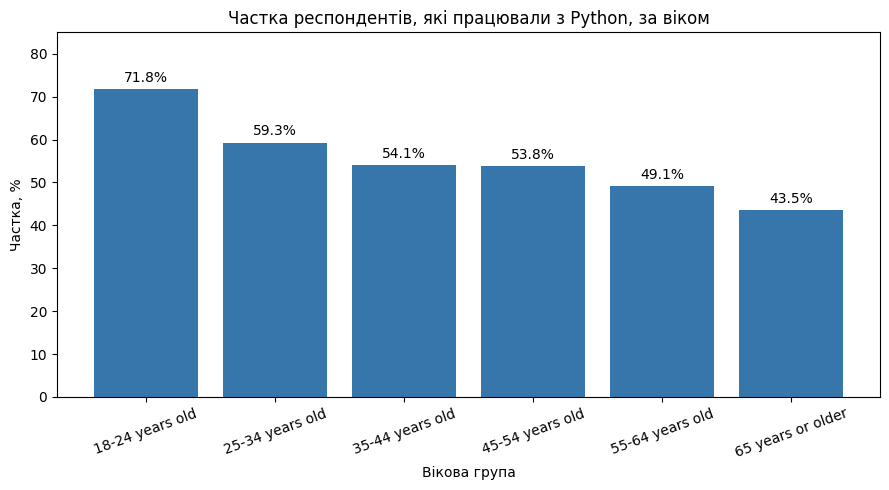

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(python_by_age["Age"], python_by_age["python_percent"], color="#3776AB")

# Підписуємо кожен стовпчик значенням
ax.bar_label(bars, fmt="%.1f%%", padding=3)

ax.set_title("Частка респондентів, які працювали з Python, за віком")
ax.set_xlabel("Вікова група")
ax.set_ylabel("Частка, %")
ax.set_ylim(0, 85)

# Нахил підписів, щоб вони не злипалися
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

**Висновок:** частка респондентів, які працювали з Python, послідовно зменшується з віком:
від 71,8% у групі 18-24 роки до 43,5% у групі 65 років і старше.
Найбільші групи (25-34 та 35-44 роки) налічують тисячі респондентів, тож їхні результати надійні.
Найменша група (65 і старше) має 678 респондентів, і її показник менш точний.
В аналізі використано 31 495 респондентів, які вказали і мови програмування, і вік.
Ще 378 респондентів обрали відповідь "Prefer not to say" щодо віку, їх не враховано.
Категорії "Under 18" у даних немає.

### 3. Як вчаться програмувати

Якими способами респонденти вчилися програмувати і яка частка з них проходила онлайн-курси?

In [8]:
# Респонденти, які відповіли на питання про способи навчання
learn_answered = df["LearnCode"].notna().sum()

# Розбиваємо відповіді на окремі способи навчання (по одному на рядок)
learn_exploded = df["LearnCode"].dropna().str.split(";").explode().str.strip()

# Скільки респондентів назвали кожен спосіб і яка це частка від тих, хто відповів
learn_counts = learn_exploded.value_counts()
learn_summary = pd.DataFrame({
    "respondents": learn_counts,
    "percent": (learn_counts / learn_answered * 100).round(1),
})

print(f"Відповіли на питання про навчання: {learn_answered}")
learn_summary

Відповіли на питання про навчання: 33556


,respondents,percent
LearnCode,,
Technical documentation (is generated for/by the tool or system),22739,67.8
"Other online resources (e.g. standard search, forum, online community)",19701,58.7
Stack Overflow or Stack Exchange,17245,51.4
Videos (not associated with specific online course or certification),16771,50.0
AI CodeGen tools or AI-enabled apps,14753,44.0
Blogs or podcasts,11688,34.8
Online Courses or Certification (includes all media types),10973,32.7
Books / Physical media,10187,30.4
Colleague or on-the-job training,8596,25.6


In [9]:
# Скільки респондентів навчалися на онлайн-курсах
df["Learned_with_online_courses"] = df["LearnCode"].str.contains("Online Courses", na=False)
online_courses_count = df["Learned_with_online_courses"].sum()

# Частка від тих, хто відповів на питання про навчання
online_courses_percent = online_courses_count / learn_answered * 100

print(f"Відповіли на питання про навчання: {learn_answered}")
print(f"Навчалися на онлайн-курсах: {online_courses_count}")
print(f"Частка: {round(online_courses_percent, 1)}%")

Відповіли на питання про навчання: 33556
Навчалися на онлайн-курсах: 10973
Частка: 32.7%


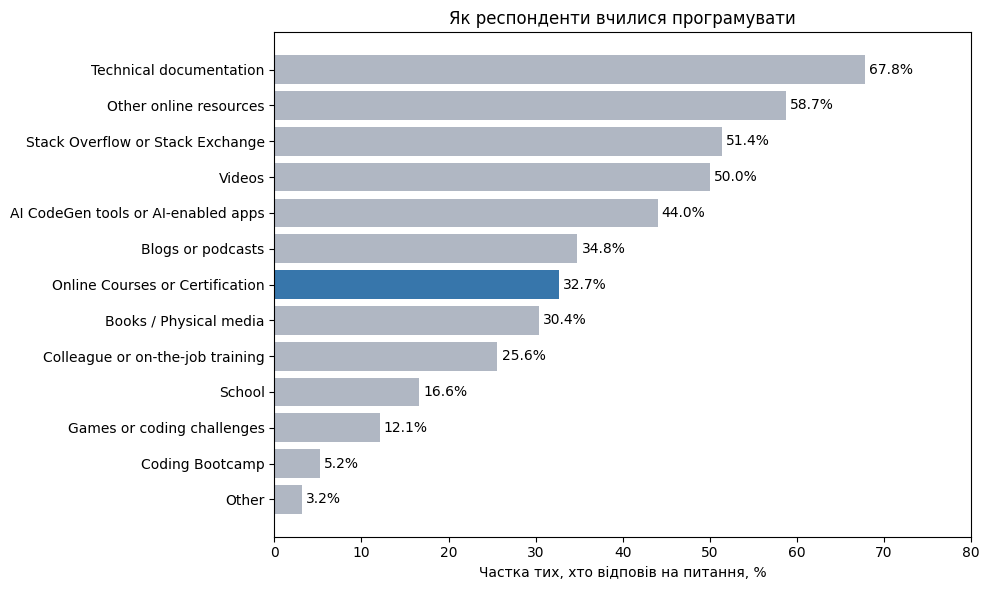

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Сортуємо за зростанням, щоб найпопулярніший спосіб був угорі
plot_data = learn_summary["percent"].sort_values()

# Скорочуємо довгі назви: лишаємо текст до дужки
labels = [name.split(" (")[0] for name in plot_data.index]

# Курси виділяємо кольором, решту робимо сірими
colors = ["#3776AB" if "Online Courses" in name else "#B0B7C3" for name in plot_data.index]

bars = ax.barh(labels, plot_data.values, color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=3)

ax.set_title("Як респонденти вчилися програмувати")
ax.set_xlabel("Частка тих, хто відповів на питання, %")
ax.set_xlim(0, 80)

plt.tight_layout()
plt.show()

**Висновок:** на питання про способи навчання відповіли 33 556 респондентів (68% вибірки).
Онлайн-курси або сертифікацію вказали 10 973 з них, тобто 32,7%.
Це сьоме місце серед способів навчання: частіше респонденти обирали технічну документацію (67,8%),
інші онлайн-ресурси (58,7%), Stack Overflow (51,4%), відео (50,0%) і навіть AI-інструменти (44,0%).
Сума відсотків перевищує 100%, бо респондент міг обрати кілька способів.
Дані показують, як часто люди користуються кожним способом, але не те, який із них був найефективнішим.

### 4. Компенсація Python-розробників за країнами

У яких країнах Python-розробники отримують найвищу річну компенсацію?

In [11]:
# Python-розробники (колонку UsesPython ми створили в підрозділі 1)
python_df = df[df["UsesPython"]]

# Скільки з них вказали компенсацію та країну
with_comp = python_df.dropna(subset=["ConvertedCompYearly", "Country"])

print(f"Python-розробників: {len(python_df)}")
print(f"З них вказали компенсацію і країну: {len(with_comp)}")

# Розподіл компенсації (в доларах на рік)
print("\nОпис компенсації:")
print(with_comp["ConvertedCompYearly"].describe().round(0))

# Скільки країн і наскільки різні за розміром групи
country_sizes = with_comp["Country"].value_counts()
print(f"\nКраїн у вибірці: {len(country_sizes)}")
print("\nНайбільші групи:")
print(country_sizes.head(10))

Python-розробників: 18410
З них вказали компенсацію і країну: 12730

Опис компенсації:
count      12730.0
mean      100115.0
std       149540.0
min            1.0
25%        40000.0
50%        76828.0
75%       128488.0
max      6371285.0
Name: ConvertedCompYearly, dtype: float64

Країн у вибірці: 153

Найбільші групи:
Country
United States of America                                3117
Germany                                                 1187
United Kingdom of Great Britain and Northern Ireland     747
France                                                   588
India                                                    541
Canada                                                   491
Netherlands                                              331
Brazil                                                   319
Spain                                                    316
Poland                                                   313
Name: count, dtype: int64


In [12]:
# Скільки країн залишається при різних мінімальних розмірах групи
for threshold in [10, 30, 50, 100]:
    n_countries = (country_sizes >= threshold).sum()
    n_people = country_sizes[country_sizes >= threshold].sum()
    print(f"Поріг {threshold}: країн {n_countries}, респондентів {n_people}")

Поріг 10: країн 76, респондентів 12485
Поріг 30: країн 53, респондентів 12072
Поріг 50: країн 42, респондентів 11674
Поріг 100: країн 23, респондентів 10284


In [13]:
MIN_RESPONDENTS = 30

compensation_by_country = (
    with_comp.groupby("Country")["ConvertedCompYearly"]
    .agg(respondents="count", average_compensation="mean", median_compensation="median")
    .query("respondents >= @MIN_RESPONDENTS")
    .sort_values("median_compensation", ascending=False)
    .round(0)
    .reset_index()
)

compensation_by_country.head(15)

,Country,respondents,average_compensation,median_compensation
0,United States of America,3117,173275.0,150000.0
1,Israel,104,135828.0,142594.0
2,Switzerland,239,156738.0,142592.0
3,Ireland,74,120524.0,116015.0
4,Denmark,120,115672.0,98289.0
5,Australia,305,118269.0,97514.0
6,United Kingdom of Great Britain and Northern I...,747,117727.0,95299.0
7,Singapore,41,147515.0,91391.0
8,Norway,88,104690.0,89439.0
9,Canada,491,102966.0,87550.0


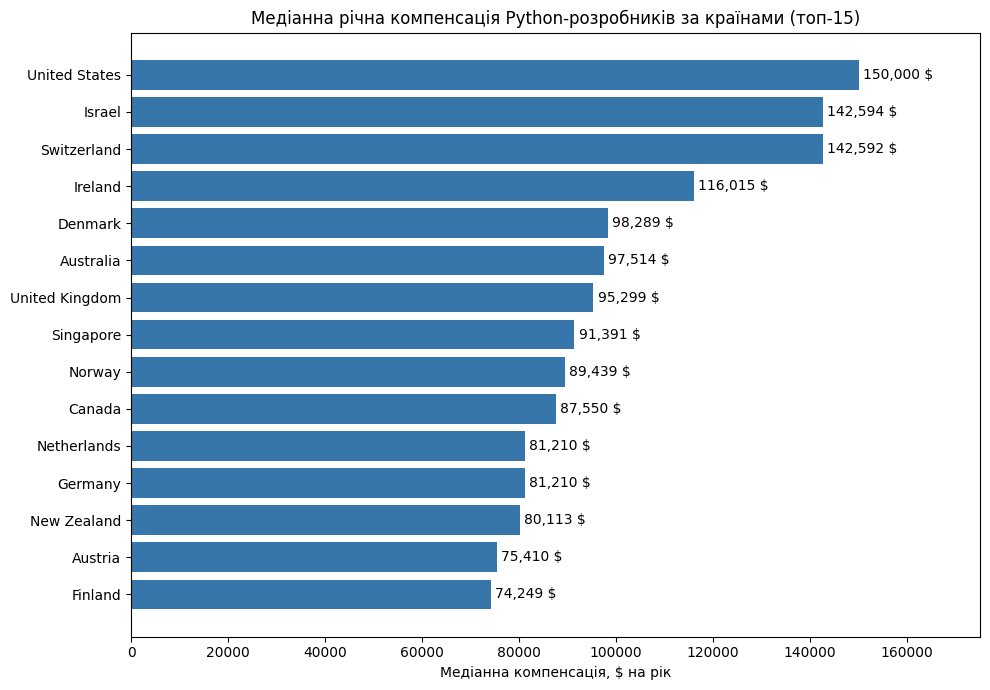

In [14]:
top15 = compensation_by_country.head(15).copy()

# Скорочуємо довгі назви країн
top15["Country"] = top15["Country"].replace({
    "United States of America": "United States",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
})

# Сортуємо за зростанням, щоб найвища медіана була вгорі
top15 = top15.sort_values("median_compensation")

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(top15["Country"], top15["median_compensation"], color="#3776AB")
ax.bar_label(bars, labels=[f"{v:,.0f} $" for v in top15["median_compensation"]], padding=3)

ax.set_title("Медіанна річна компенсація Python-розробників за країнами (топ-15)")
ax.set_xlabel("Медіанна компенсація, $ на рік")
ax.set_xlim(0, 175000)

plt.tight_layout()
plt.show()

**Висновок:** компенсацію та країну вказали 12 730 з 18 410 Python-розробників (69%).
Через великий розкид значень (від 1 USD до понад 6 млн USD) основною мірою обрано медіану:
загальна медіана становить 76 828 USD, тоді як середнє значно вище (100 115 USD).
До аналізу увійшли 53 країни, у яких є щонайменше 30 респондентів (12 072 людини).
Найвища медіана у США (150 000 USD), далі йдуть Ізраїль (142 594 USD) та Швейцарія (142 592 USD).
Показники подано в доларах на рік без урахування вартості життя,
тому вони порівнюють номінальну компенсацію, а не купівельну спроможність.

### 5. Індустрії високооплачуваних віддалених працівників

У яких індустріях працюють Python-розробники з найвищою компенсацією, які працюють віддалено?

In [15]:
# Python-розробники, які вказали компенсацію
python_comp = python_df.dropna(subset=["ConvertedCompYearly"])

# 75-й перцентиль: межа, вище якої лежать 25% найвищих компенсацій
q75 = python_comp["ConvertedCompYearly"].quantile(0.75)
print(f"Python-розробників з компенсацією: {len(python_comp)}")
print(f"75-й перцентиль: {q75:,.0f} $")

print("\nФормат роботи (RemoteWork):")
print(python_comp["RemoteWork"].value_counts(dropna=False))

print("\nІндустрії (Industry), перші 15:")
print(python_comp["Industry"].value_counts(dropna=False).head(15))

Python-розробників з компенсацією: 12730
75-й перцентиль: 128,488 $

Формат роботи (RemoteWork):
RemoteWork
Remote                                                                          3544
Hybrid (some remote, leans heavy to in-person)                                  2340
Hybrid (some in-person, leans heavy to flexibility)                             2110
In-person                                                                       1859
Your choice (very flexible, you can come in when you want or just as needed)    1533
NaN                                                                             1344
Name: count, dtype: int64

Індустрії (Industry), перші 15:
Industry
Software Development                          5373
Other:                                        1131
Internet, Telecomm or Information Services     711
Fintech                                        592
Higher Education                               554
Healthcare                                     554
Banking/

In [16]:
# Високооплачувані (вище 75-го перцентиля) віддалені Python-розробники
high_remote = python_comp[
    (python_comp["ConvertedCompYearly"] > q75)
    & (python_comp["RemoteWork"] == "Remote")
]

# Рахуємо частки лише серед тих, хто вказав індустрію
group_industries = high_remote["Industry"].dropna()
all_industries = python_comp["Industry"].dropna()

print(f"У групі: {len(high_remote)} респондентів, індустрію вказали {len(group_industries)}")
print(f"Усі Python-розробники з компенсацією, індустрію вказали: {len(all_industries)}")

industry_summary = pd.DataFrame({
    "count": group_industries.value_counts(),
    "group_percent": (group_industries.value_counts(normalize=True) * 100).round(1),
    "all_percent": (all_industries.value_counts(normalize=True) * 100).round(1),
}).dropna(subset=["count"])

industry_summary["difference"] = (industry_summary["group_percent"] - industry_summary["all_percent"]).round(1)

industry_summary = pd.DataFrame({
    "count": group_industries.value_counts(),
    "group_percent": (group_industries.value_counts(normalize=True) * 100).round(1),
    "all_percent": (all_industries.value_counts(normalize=True) * 100).round(1),
}).dropna(subset=["count"])

industry_summary["difference"] = (industry_summary["group_percent"] - industry_summary["all_percent"]).round(1)

# Сортуємо за кількістю респондентів у групі, від більшої до меншої
industry_summary = industry_summary.sort_values("count", ascending=False)

industry_summary.head(10)



У групі: 1265 респондентів, індустрію вказали 1265
Усі Python-розробники з компенсацією, індустрію вказали: 12243


,count,group_percent,all_percent,difference
Industry,,,,
Software Development,599,47.4,43.9,3.5
Fintech,98,7.7,4.8,2.9
Other:,96,7.6,9.2,-1.6
Healthcare,92,7.3,4.5,2.8
"Internet, Telecomm or Information Services",80,6.3,5.8,0.5
Government,49,3.9,3.9,0.0
Media & Advertising Services,42,3.3,2.6,0.7
Computer Systems Design and Services,36,2.8,2.9,-0.1
"Transportation, or Supply Chain",31,2.5,2.8,-0.3


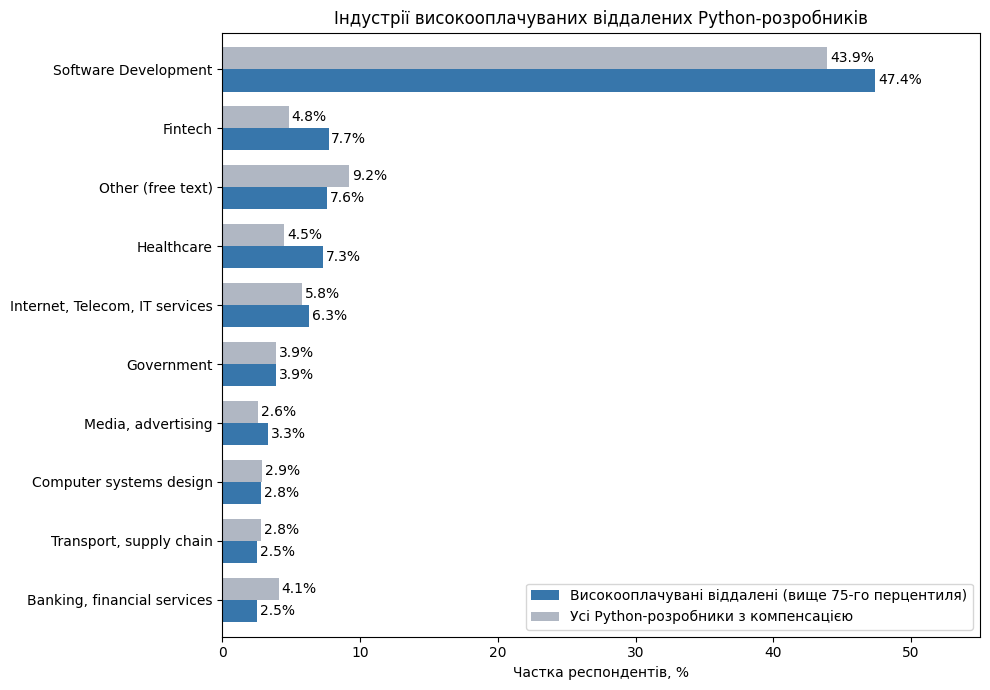

In [17]:
top10 = industry_summary.head(10).copy()

# Скорочуємо довгі назви та пояснюємо категорію "Other:"
top10 = top10.rename(index={
    "Other:": "Other (free text)",
    "Internet, Telecomm or Information Services": "Internet, Telecom, IT services",
    "Computer Systems Design and Services": "Computer systems design",
    "Transportation, or Supply Chain": "Transport, supply chain",
    "Banking/Financial Services": "Banking, financial services",
    "Media & Advertising Services": "Media, advertising",
})

# Розвертаємо порядок, щоб найбільша індустрія була вгорі
top10 = top10.iloc[::-1]

ax = top10[["group_percent", "all_percent"]].plot.barh(
    figsize=(10, 7), color=["#3776AB", "#B0B7C3"], width=0.75
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2)

ax.set_title("Індустрії високооплачуваних віддалених Python-розробників")
ax.set_xlabel("Частка респондентів, %")
ax.set_ylabel("")
ax.set_xlim(0, 55)
ax.legend(["Високооплачувані віддалені (вище 75-го перцентиля)",
           "Усі Python-розробники з компенсацією"], loc="lower right")

plt.tight_layout()
plt.show()

**Висновок:** до групи високооплачуваних віддалених Python-розробників
(компенсація вище 128 488 $, формат роботи Remote) увійшли 1 265 респондентів.
Майже половина з них (47,4%) працює в Software Development, але ця індустрія
найбільша і серед усіх Python-розробників (43,9%), тож перевага невелика (+3,5 п.п.).
Помітніше вирізняються Fintech (7,7% проти 4,8%) та Healthcare (7,3% проти 4,5%):
їхня частка в групі приблизно в 1,6 раза вища за загальну.
Це опис збігу в даних, а не пояснення причини, і значущість різниці ми не перевіряли.
Індустрії з дуже малою кількістю респондентів у групі (наприклад, Higher Education, 12 осіб)
не інтерпретуємо. Категорія "Other:" це вільні відповіді, а не окрема галузь.

## Висновки

Аналіз побудовано на даних опитування Stack Overflow 2025 (49 191 респондент).
Основні результати щодо Python-розробників:

- **Популярність.** З Python працювали 58,1% респондентів, які відповіли на питання про мови програмування (18 410 із 31 671).
- **Вік.** Частка Python-розробників зменшується з віком: від 71,8% у групі 18-24 роки до 43,5% у групі 65 років і старше.
- **Навчання.** Онлайн-курси або сертифікацію вказали 32,7% респондентів, і це лише сьомий за популярністю спосіб. Частіше обирали технічну документацію (67,8%), інші онлайн-ресурси (58,7%), Stack Overflow (51,4%) та відео (50,0%).
- **Компенсація.** Медіанна річна компенсація Python-розробників становить 76 828 USD, а середнє значно вище (100 115 USD) через поодинокі дуже великі значення. Серед країн, де є щонайменше 30 респондентів, найвища медіана у США (150 000 USD), Ізраїлю (142 594 USD) та Швейцарії (142 592 USD).
- **Індустрії.** Серед високооплачуваних віддалених Python-розробників (компенсація вище 128 488 USD) вирізняються Fintech (7,7% проти 4,8% серед усіх) та Healthcare (7,3% проти 4,5%). Software Development найбільша індустрія в обох групах, тож її лідерство не є особливістю цієї групи.

**Обмеження.** Опитування добровільне, тому вибірка не обов'язково відображає всіх розробників.
Частину питань пропустили (компенсацію вказали 69% Python-розробників),
а компенсація подана в доларах без урахування вартості життя.
Результати описують зв'язки в даних і не пояснюють їхніх причин.